# Valutazione Classificatori su Validation Set — Fine-tuning Parziale vs Completo

Confronto delle due configurazioni di fine-tuning ResNet-50 addestrate su dati reali + sintetici:

| Versione | Livelli Scongelati |
|---|---|
| **Versione1** | Parziali (31%) |
| **Versione2** | Tutti |

**Obiettivo:** selezione della configurazione migliore (*model selection*) prima della valutazione finale sul test set.

**Nota metodologica:**  
Il validation set è composto solo da immagini reali ed è già stato usato durante il training (early stopping su `val_auc` e calibrazione della soglia di Youden). Di conseguenza:

- **AUC** è il criterio primario di selezione: è indipendente dalla soglia e riflette la capacità discriminativa del modello.
- **Accuracy, Precision, Recall, F1 e Confusion Matrix** sono metriche soglia-dipendenti. Poiché le soglie sono state calibrate su questo stesso validation set, hanno valore *descrittivo* e non vanno interpretate come stime di generalizzazione.
- **Distribuzione delle probabilità predette**: è indipendente dalla soglia, quindi l'analisi di incertezza sistematica e overconfidence resta pienamente valida.

Il test set rimane riservato alla valutazione finale della sola configurazione selezionata.

#### Verifica dell'ambiente di lavoro

Viene calcolato il percorso base sulla base dell'ambiente di lavoro utilizzato (Locale o Google Colab)

In [1]:
import os
import sys

if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = '/content/drive/MyDrive/MammoDiffusion/'
else:
    print("Ambiente locale rilevato.")
    BASE_PATH = '../'

print(f"Percorso base: {BASE_PATH}")


Ambiente locale rilevato.
Percorso base: ../


#### Import librerie


In [3]:
import zipfile
import gdown
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import (
    confusion_matrix, roc_curve, roc_auc_score,
    classification_report, precision_score, recall_score, f1_score
)

#### Configurazione

Percorsi degli esperimenti, ID Google Drive per il download dei modelli e delle metriche,
parametri di preprocessing e directory di output.

In [4]:
# Definizione percorsi degli esperimenti
REAL_SYNTH_EXP_DIR = os.path.join(BASE_PATH, 'experiments', 'exp20260617_real_synth_resnet50_fine_tuned_batch_size_16')
REAL_SYNTH_ALL_LAYERS_EXP_DIR = os.path.join(BASE_PATH, 'experiments', 'exp20260618_real_synth_resnet50_fine_tuned_all_layers')

# Drive ID dei modelli salvati in Google Drive
REAL_SYNTH_MODEL_DRIVE_ID = '11f9pcL8kbLz7hi6i3lqDuferljdRl2uV'
REAL_SYNTH_ALL_LAYERS_MODEL_DRIVE_ID = '12lQfdsi3jWpfwIz8Q0ESAIoNzc8DNMqM'

# Drive ID dei JSON contenenti le metriche calcolate sul validation set
REAL_SYNTH_METRICS_DRIVE_ID = '1J55coTQluAadvUsusaR2uzP5juNCYnKx'
REAL_SYNTH_ALL_LAYERS_METRICS_DRIVE_ID = '1yCfR9CmRLHn_y3gDTdpHKw214lGdFvhD'

# Definizione del Dataset di validazione
PROCESSED_DRIVE_ID = "1qQral_BIBlMl0QN3PllJukdYTOmNGWr3"
VAL_CSV_PATH = os.path.join(BASE_PATH, 'data', 'processed', 'metadata', 'val.csv')

# Preprocessing
IMG_SIZE = (224, 224) # Dimensione standard per ResNet-50
BATCH_SIZE = 16
SEED = 42
IMAGENET_MEAN = tf.constant([0.485, 0.456, 0.406])
IMAGENET_STD  = tf.constant([0.229, 0.224, 0.225])
AUTOTUNE = tf.data.AUTOTUNE

# Definizione cartelle di output (output risultati, figure, tabelle e predizioni)
OUTPUT_DIR      = os.path.join(BASE_PATH, 'results', '07_val_classificatori_allVSpart')
FIGURES_DIR     = os.path.join(OUTPUT_DIR, 'figures')
TABLES_DIR      = os.path.join(OUTPUT_DIR, 'tables')
PREDICTIONS_DIR = os.path.join(OUTPUT_DIR, 'predictions')

for dir in (OUTPUT_DIR, FIGURES_DIR, TABLES_DIR, PREDICTIONS_DIR):
    os.makedirs(dir, exist_ok=True)

print(f"Output salvato in: {OUTPUT_DIR}")
print(f"  figures/     => {FIGURES_DIR}")
print(f"  tables/      => {TABLES_DIR}")
print(f"  predictions/ => {PREDICTIONS_DIR}")

Output salvato in: ../results/07_val_classificatori_allVSpart
  figures/     => ../results/07_val_classificatori_allVSpart/figures
  tables/      => ../results/07_val_classificatori_allVSpart/tables
  predictions/ => ../results/07_val_classificatori_allVSpart/predictions


E0000 00:00:1781874604.465069    8232 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (100)


#### Verifica Presenza Dataset Preprocessato

In [5]:
# Percorso dello zip del dataset preprocessato
PROCESSED_ZIP = os.path.join(BASE_PATH, 'data', 'processed', 'processed.zip')

def verifica_processed_data():
    if not os.path.isfile(VAL_CSV_PATH):
        return False
    try:
        first_path = pd.read_csv(VAL_CSV_PATH)['processed_path'].iloc[0]
        return os.path.isfile(os.path.join(BASE_PATH, first_path))
    except Exception:
        return False

if not verifica_processed_data():
    print("Dataset non trovato, scarico da Google Drive...")
    os.makedirs(os.path.dirname(PROCESSED_ZIP), exist_ok=True)
    gdown.download(id=PROCESSED_DRIVE_ID, output=PROCESSED_ZIP, quiet=False)
    with zipfile.ZipFile(PROCESSED_ZIP, 'r') as z:
        z.extractall(os.path.join(BASE_PATH, 'data', 'processed'))
    os.remove(PROCESSED_ZIP)
    print("Dataset estratto")
else:
    print("Dataset già presente, salto il download")

Dataset già presente, salto il download


#### Creazione Dataset di Validation

Utilizzo del file `val.csv` del dataset preprocessato, che contiene le immagini usate durante il training per early stopping e calibrazione della soglia. Non viene utilizzata augmentation, solo preprocessing identico a quello utilizzato in training.

In [6]:
df_val = pd.read_csv(VAL_CSV_PATH).reset_index(drop=True)

n_positivi = (df_val['cancer'] == 1).sum()
n_negativi = (df_val['cancer'] == 0).sum()
print(f"Validation set: {len(df_val)} immagini  (cancer=1: {n_positivi}, cancer=0: {n_negativi})")

def caricamento_preprocessing(percorso, etichetta):
    img_real = tf.io.read_file(percorso)
    img = tf.image.decode_image(img_real, channels=1, expand_animations=False) # da 3 canali a 1 canale
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    img = tf.repeat(img, repeats=3, axis=-1) # grayscale => 3 canali per ResNet-50
    img = (img - IMAGENET_MEAN) / IMAGENET_STD
    return img, tf.cast(etichetta, tf.float32)

def crea_dataset_val(df):
    percorsi  = [os.path.join(BASE_PATH, p) for p in df['processed_path'].values]
    etichette = df['cancer'].values
    ds = tf.data.Dataset.from_tensor_slices((percorsi, etichette))
    ds = ds.map(lambda p, l: caricamento_preprocessing(p, l), num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

val_ds = crea_dataset_val(df_val)
print("Dataset di validation pronto")

Validation set: 437 immagini  (cancer=1: 73, cancer=0: 364)
Dataset di validation pronto


#### Caricamento Modelli

Logica di caricamento (in ordine di priorità):
1. Cartella esperimento locale (`experiments/exp.../`)
2. Cartella `results/07_val_classificatori_allVSpart/models/` (se scaricati in precedenza)
3. Download da Google Drive → salvato in `results/07_val_classificatori_allVSpart/models/`

In [7]:
MODELS_DIR = os.path.join(OUTPUT_DIR, 'models')
os.makedirs(MODELS_DIR, exist_ok=True)

MODELS_CONFIG = {
    'Real+Synth_Part': {
        'percorso_exp':   os.path.join(REAL_SYNTH_EXP_DIR, 'real_synth_resnet50_final_best.keras'),
        'percorso_modello': os.path.join(MODELS_DIR,          'real_synth_resnet50_final_best.keras'),
        'drive_id':   REAL_SYNTH_MODEL_DRIVE_ID,
    },
    'Real+Synth_All_Layers': {
        'percorso_exp':   os.path.join(REAL_SYNTH_ALL_LAYERS_EXP_DIR, 'real_synth_resnet50_all_layers_final_best.keras'),
        'percorso_modello': os.path.join(MODELS_DIR,          'real_synth_resnet50_all_layers_final_best.keras'),
        'drive_id':   REAL_SYNTH_ALL_LAYERS_MODEL_DRIVE_ID,
    },
}

def caricamento_classificatore(nome_conf, config):
    # Cartella esperimento locale
    if os.path.isfile(config['percorso_exp']):
        print(f"[{nome_conf}] Carico dalla cartella esperimento")
        return keras.models.load_model(config['percorso_exp'])

    # Cache in results/models/
    if os.path.isfile(config['percorso_modello']):
        print(f"[{nome_conf}] Carico dalla cartella models")
        return keras.models.load_model(config['percorso_modello'])

    # Download da Drive
    print(f"[{nome_conf}] Modello non trovato localmente, scarico da Google Drive...")
    gdown.download(id=config['drive_id'], output=config['percorso_modello'], quiet=False)
    print(f"[{nome_conf}] Salvato in: {config['percorso_modello']}")
    return keras.models.load_model(config['percorso_modello'])

real_synth_model = caricamento_classificatore('Real+Synth_Part', MODELS_CONFIG['Real+Synth_Part'])
real_synth_all_layers_model = caricamento_classificatore('Real+Synth_All_Layers', MODELS_CONFIG['Real+Synth_All_Layers'])

print("\nTutti i modelli caricati.")

[Real+Synth_Part] Carico dalla cartella esperimento
[Real+Synth_All_Layers] Carico dalla cartella esperimento

Tutti i modelli caricati.


#### Caricamento Soglie Ottimali dal Validation Set

Le soglie ottimali (indice di Youden: J = TPR − FPR) sono state salvate in `val_metrics.json` durante il training.
Vengono utilizzate quelle per non essere ricalcolate sul set di test

Logica di caricamento (in ordine di priorità):
1. Cartella esperimento locale (`experiments/exp.../val_metrics.json`)
2. Cache in `results/07_val_classificatori_allVSpart/val_metrics/`
3. Download da Google Drive → salvato nella cartella val_metrics

In [8]:
VAL_METRICS_DIR = os.path.join(OUTPUT_DIR, 'val_metrics')
os.makedirs(VAL_METRICS_DIR, exist_ok=True)

METRICS_CONFIG = {
    'Real+Synth_Part': {
        'percorso_exp':   os.path.join(REAL_SYNTH_EXP_DIR, 'val_metrics.json'),
        'percorso_metriche': os.path.join(VAL_METRICS_DIR,     'real_synth_val_metrics.json'),
        'drive_id':   REAL_SYNTH_METRICS_DRIVE_ID,
    },
    'Real+Synth_All_Layers': {
        'percorso_exp':   os.path.join(REAL_SYNTH_ALL_LAYERS_EXP_DIR, 'val_metrics.json'),
        'percorso_metriche': os.path.join(VAL_METRICS_DIR,     'real_synth_all_layers_val_metrics.json'),
        'drive_id':   REAL_SYNTH_ALL_LAYERS_METRICS_DRIVE_ID,
    }
}

def load_val_metrics(nome, config):
    # Cartella esperimento locale
    if os.path.isfile(config['percorso_exp']):
        print(f"[{nome}] Carico val_metrics dalla cartella esperimento")
        with open(config['percorso_exp']) as f:
            return json.load(f)

    # Cache in results/val_metrics/
    if os.path.isfile(config['percorso_metriche']):
        print(f"[{nome}] Carico val_metrics dalla cartella metriche")
        with open(config['percorso_metriche']) as f:
            return json.load(f)

    # Download da Drive
    print(f"[{nome}] val_metrics.json non trovato, scarico da Google Drive...")
    gdown.download(id=config['drive_id'], output=config['percorso_metriche'], quiet=False)
    print(f"[{nome}] Salvato in: {config['percorso_metriche']}")
    with open(config['percorso_metriche']) as f:
        return json.load(f)

metriche_real_synth = load_val_metrics('Real+Synth_Part', METRICS_CONFIG['Real+Synth_Part'])
metriche_real_synth_all_layers = load_val_metrics('Real+Synth_All_Layers', METRICS_CONFIG['Real+Synth_All_Layers'])

real_synth_threshold = metriche_real_synth['optimal_threshold_youden']
real_synth_all_layers_threshold = metriche_real_synth_all_layers['optimal_threshold_youden']

print("\nSoglie ottimali (dal validation set):")
print(f"  Real+Synth_Part:        {real_synth_threshold:.3f}")
print(f"  Real+Synth_All_Layers:  {real_synth_all_layers_threshold:.3f}")

[Real+Synth_Part] Carico val_metrics dalla cartella esperimento
[Real+Synth_All_Layers] Carico val_metrics dalla cartella esperimento

Soglie ottimali (dal validation set):
  Real+Synth_Part:        0.269
  Real+Synth_All_Layers:  0.161


#### Predizioni sul Validation Set

Raccolta delle probabilità predette da ciascun modello su tutti i batch del validation set.

In [9]:
def predizioni_val_set(modello, dataset):
    y_true_list, y_prob_list = [], []
    for imgs, labels in dataset:
        probs = modello.predict(imgs, verbose=0)
        y_prob_list.extend(probs.flatten())
        y_true_list.extend(labels.numpy())
    return np.array(y_true_list), np.array(y_prob_list)

print("Predizioni Real+Synth_Part...")
y_true, real_synth_probs = predizioni_val_set(real_synth_model, val_ds)
print("Predizioni Real+Synth_All_Layers...")
_,      real_synth_all_layers_probs = predizioni_val_set(real_synth_all_layers_model, val_ds)
print("Predizioni completate")

Predizioni Real+Synth_Part...


I0000 00:00:1781874629.582042    8825 service.cc:153] XLA service 0x7399cc06bb40 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781874629.582174    8825 service.cc:161]   StreamExecutor [0]: Host, Default Version (Driver: 0.0.0; Runtime: 0.0.0; Toolkit: 0.0.0; DNN: 0.0.0)
I0000 00:00:1781874629.753546    8825 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1781874631.320243    8825 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Predizioni Real+Synth_All_Layers...
Predizioni completate


#### Salvataggio Predizioni

Le probabilità predette e le etichette binarie (applicando le soglie ottimali del validation set) vengono salvate in CSV per analisi successive.

In [10]:
df_predizioni = df_val[['processed_path', 'cancer']].copy().rename(columns={'cancer': 'label_true'})

df_predizioni['prob_real_synth'] = real_synth_probs
df_predizioni['prob_real_synth_all_layers'] = real_synth_all_layers_probs


df_predizioni['pred_real_synth'] = (real_synth_probs >= real_synth_threshold).astype(int)
df_predizioni['pred_real_synth_all_layers'] = (real_synth_all_layers_probs >= real_synth_all_layers_threshold).astype(int)

preds_path = os.path.join(PREDICTIONS_DIR, 'val_predictions.csv')
df_predizioni.to_csv(preds_path, index=False)
print(f"Predizioni salvate in: {preds_path}")

Predizioni salvate in: ../results/07_val_classificatori_allVSpart/predictions/val_predictions.csv


#### Valutazione — Metriche per Configurazione

In [11]:
CLASSIFICATORI = {
    'Real+Synth_Part':       (real_synth_probs,            real_synth_threshold),
    'Real+Synth_All_Layers': (real_synth_all_layers_probs, real_synth_all_layers_threshold),
}

all_metrics = {}

for nome_conf, (probs, threshold) in CLASSIFICATORI.items():
    fpr, tpr, _ = roc_curve(y_true, probs)
    auc = roc_auc_score(y_true, probs)

    y_pred = (probs >= threshold).astype(int)

    all_metrics[nome_conf] = {
        'auc':       round(float(auc), 4),
        'threshold': round(float(threshold), 4),
        'accuracy':  round(float((y_pred == y_true).mean()), 4),
        'precision': round(float(precision_score(y_true, y_pred, pos_label=1, zero_division=0)), 4),
        'recall':    round(float(recall_score(y_true, y_pred, pos_label=1, zero_division=0)), 4),
        'f1':        round(float(f1_score(y_true, y_pred, pos_label=1, zero_division=0)), 4),
        'fpr': fpr, 'tpr': tpr, 'y_pred': y_pred,
    }

    print(f"\n{'='*52}")
    print(f"  {nome_conf}")
    print(f"{'='*52}")
    print(f"  AUC:       {auc:.4f}")
    print(f"  Soglia:    {threshold:.3f}")
    print(f"  Accuracy:  {all_metrics[nome_conf]['accuracy']:.4f}")
    print(f"  Precision: {all_metrics[nome_conf]['precision']:.4f}")
    print(f"  Recall:    {all_metrics[nome_conf]['recall']:.4f}")
    print(f"  F1:        {all_metrics[nome_conf]['f1']:.4f}")
    print(classification_report(y_true, y_pred, target_names=['No cancro', 'Cancro']))

# Salva JSON in tables
metrics_to_save = {
    k: {m: v for m, v in vals.items() if m not in ('fpr', 'tpr', 'y_pred')}
    for k, vals in all_metrics.items()
}
val_comparison_metrics_path = os.path.join(TABLES_DIR, 'val_comparison_metrics.json')
with open(val_comparison_metrics_path, 'w') as f:
    json.dump(metrics_to_save, f, indent=2, ensure_ascii=False)
print(f"\nMetriche salvate in: {val_comparison_metrics_path}")


  Real+Synth_Part
  AUC:       0.6846
  Soglia:    0.269
  Accuracy:  0.5835
  Precision: 0.2465
  Recall:    0.7260
  F1:        0.3681
              precision    recall  f1-score   support

   No cancro       0.91      0.55      0.69       364
      Cancro       0.25      0.73      0.37        73

    accuracy                           0.58       437
   macro avg       0.58      0.64      0.53       437
weighted avg       0.80      0.58      0.64       437


  Real+Synth_All_Layers
  AUC:       0.6310
  Soglia:    0.161
  Accuracy:  0.6293
  Precision: 0.2541
  Recall:    0.6301
  F1:        0.3622
              precision    recall  f1-score   support

   No cancro       0.89      0.63      0.74       364
      Cancro       0.25      0.63      0.36        73

    accuracy                           0.63       437
   macro avg       0.57      0.63      0.55       437
weighted avg       0.79      0.63      0.68       437


Metriche salvate in: ../results/07_val_classificatori_allVSpart

#### Analisi Distribuzione Probabilità Predette per Classe Reale

Per ciascun modello, le probabilità predette vengono separate in base alla classe reale (`y_true`) per distinguere due scenari di errore:
- **Incertezza sistematica**: le probabilità si addensano vicino alla soglia decisionale (fascia centrale ± 0.15).
- **Overconfidence nella direzione sbagliata**: le probabilità si concentrano vicino agli estremi (< 0.10 o > 0.90), ma nella direzione opposta rispetto alla classe vera.

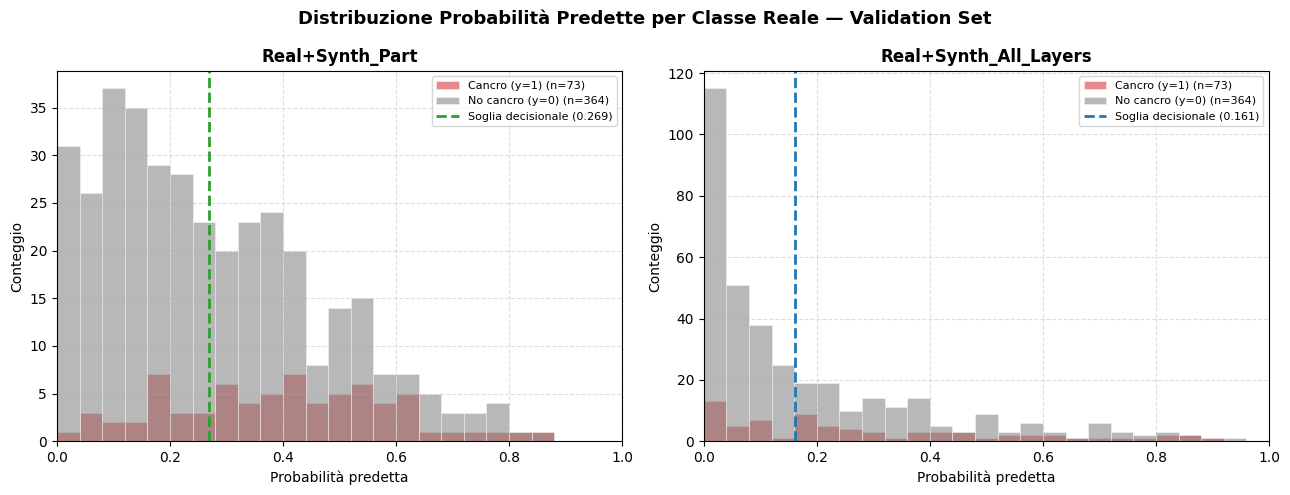

Salvato in: ../results/07_val_classificatori_allVSpart/figures/val_probability_distributions.png


In [12]:
COLORI_CLASSE    = {1: 'tab:red', 0: 'tab:gray'}
ETICHETTE_CLASSE = {1: 'Cancro (y=1)', 0: 'No cancro (y=0)'}
COLORS = {'Real+Synth_Part': 'tab:green', 'Real+Synth_All_Layers': 'tab:blue'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (nome_conf, (probs, soglia)) in zip(axes, CLASSIFICATORI.items()):
    for classe in [1, 0]:
        maschera = (y_true == classe)
        prob_classe = probs[maschera]
        ax.hist(
            prob_classe,
            bins=25,
            range=(0, 1),
            alpha=0.55,
            color=COLORI_CLASSE[classe],
            label=f"{ETICHETTE_CLASSE[classe]} (n={int(maschera.sum())})",
            edgecolor='white',
            linewidth=0.5,
        )

    ax.axvline(
        x=soglia,
        color=COLORS[nome_conf],
        linestyle='--',
        linewidth=2,
        label=f'Soglia decisionale ({soglia:.3f})',
    )
    ax.set_xlim(0, 1)
    ax.set_xlabel('Probabilità predetta')
    ax.set_ylabel('Conteggio')
    ax.set_title(nome_conf, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.4)

fig.suptitle('Distribuzione Probabilità Predette per Classe Reale — Validation Set',
             fontsize=13, fontweight='bold')
plt.tight_layout()

dist_path = os.path.join(FIGURES_DIR, 'val_probability_distributions.png')
fig.savefig(dist_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Salvato in: {dist_path}")

#### Statistiche Distribuzione per Classe

Calcolo di media, deviazione standard, percentuale di campioni nella fascia centrale (incertezza sistematica) e percentuale di campioni overconfident nella direzione errata.

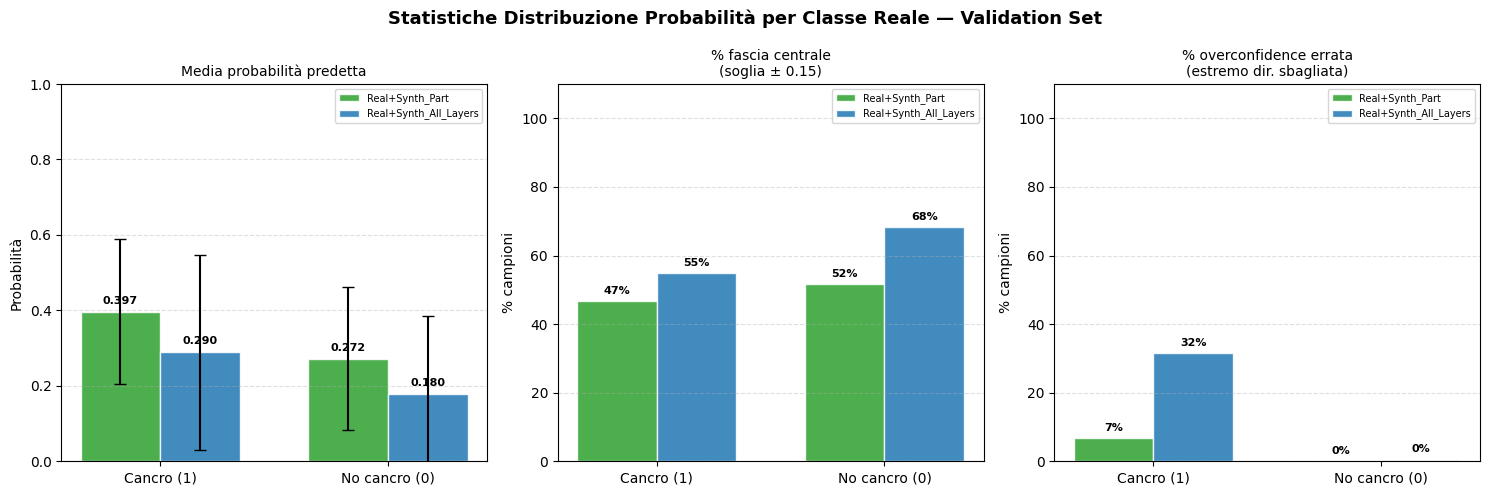

Figura salvata in:      ../results/07_val_classificatori_allVSpart/figures/val_probability_distribution_stats.png
Tabella CSV salvata in: ../results/07_val_classificatori_allVSpart/tables/val_probability_distribution_stats.csv


In [13]:
# Parametri per le statistiche di distribuzione
AMPIEZZA_FASCIA = 0.15   # fascia centrale: soglia ± AMPIEZZA_FASCIA
SOGLIA_ESTREMO  = 0.10   # estremi: prob < SOGLIA_ESTREMO o > (1 - SOGLIA_ESTREMO)

righe_stats = []

for nome_conf, (probs, soglia) in CLASSIFICATORI.items():
    for classe in [1, 0]:
        maschera = (y_true == classe)
        prob_classe = probs[maschera]
        n = int(maschera.sum())

        media = float(prob_classe.mean())
        std   = float(prob_classe.std())

        # Incertezza sistematica: campioni vicini alla soglia decisionale
        nella_fascia = (
            (prob_classe >= soglia - AMPIEZZA_FASCIA) &
            (prob_classe <= soglia + AMPIEZZA_FASCIA)
        )
        pct_fascia = round(100.0 * nella_fascia.sum() / n, 1)

        # Overconfidence nella direzione sbagliata:
        # classe cancro (1)    → prob < SOGLIA_ESTREMO   (sicuro: no-cancro, ma è cancro)
        # classe no-cancro (0) → prob > 1−SOGLIA_ESTREMO (sicuro: cancro,    ma è no-cancro)
        if classe == 1:
            errata = prob_classe < SOGLIA_ESTREMO
        else:
            errata = prob_classe > (1 - SOGLIA_ESTREMO)
        pct_overconfidence_errata = round(100.0 * errata.sum() / n, 1)

        righe_stats.append({
            'Modello':                   nome_conf,
            'Classe_reale':              'Cancro (1)' if classe == 1 else 'No cancro (0)',
            'N_campioni':                n,
            'Media_prob':                round(media, 4),
            'Std_prob':                  round(std, 4),
            'Pct_fascia_centrale':       pct_fascia,
            'Pct_overconfidence_errata': pct_overconfidence_errata,
        })

df_stats_prob = (
    pd.DataFrame(righe_stats)
    .set_index(['Modello', 'Classe_reale'])
)

stats_path = os.path.join(TABLES_DIR, 'val_probability_distribution_stats.csv')
df_stats_prob.to_csv(stats_path)

#  Visualizzazione Istogramma
classi_ordine = ['Cancro (1)', 'No cancro (0)']
x = np.arange(len(classi_ordine))
width = 0.35

metriche_grafici = [
    ('Media_prob',                'Media probabilità predetta',                          'Probabilità', (0, 1.0), False),
    ('Pct_fascia_centrale',       f'% fascia centrale\n(soglia ± {AMPIEZZA_FASCIA})',    '% campioni',  (0, 110), True),
    ('Pct_overconfidence_errata', f'% overconfidence errata\n(estremo dir. sbagliata)',  '% campioni',  (0, 110), True),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (metrica, titolo, ylabel, ylim, is_pct) in zip(axes, metriche_grafici):
    for i, (nome_conf, colore) in enumerate(COLORS.items()):
        valori = [df_stats_prob.loc[(nome_conf, cls), metrica] for cls in classi_ordine]
        errori = (
            [df_stats_prob.loc[(nome_conf, cls), 'Std_prob'] for cls in classi_ordine]
            if metrica == 'Media_prob' else None
        )
        bars = ax.bar(
            x + i * width, valori, width,
            label=nome_conf, color=colore, alpha=0.85, edgecolor='white',
            yerr=errori, capsize=4 if errori else 0,
            error_kw={'elinewidth': 1.5, 'ecolor': 'black'} if errori else {},
        )
        for bar, v in zip(bars, valori):
            etichetta = f'{v:.0f}%' if is_pct else f'{v:.3f}'
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + (0.015 if not is_pct else 1.5),
                    etichetta, ha='center', va='bottom', fontsize=8, fontweight='bold')

    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(classi_ordine)
    ax.set_ylim(*ylim)
    ax.set_ylabel(ylabel)
    ax.set_title(titolo, fontsize=10)
    ax.legend(fontsize=7)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

fig.suptitle('Statistiche Distribuzione Probabilità per Classe Reale — Validation Set',
             fontsize=13, fontweight='bold')
plt.tight_layout()

stats_fig_path = os.path.join(FIGURES_DIR, 'val_probability_distribution_stats.png')
fig.savefig(stats_fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Figura salvata in:      {stats_fig_path}")
print(f"Tabella CSV salvata in: {stats_path}")

#### Grad-CAM — Esempi Qualitativi per Categoria

Per ciascun modello vengono selezionati 4 campioni rappresentativi lungo due assi:
- **Correttezza**: predizione corretta vs errata
- **Confidenza**: alta (massima distanza dalla soglia decisionale) vs bassa (minima distanza, caso "al limite")

Le combinazioni risultanti sono: Corretto/Alta confidenza, Corretto/Bassa confidenza, Sbagliato/Alta confidenza (overconfidence errata), Sbagliato/Bassa confidenza (errore di misura).

In [14]:
# Funzioni Grad-CAM

def make_gradcam_heatmap(img_array, model):
    backbone = model.get_layer('resnet50')
    head_layers = [l for l in model.layers
                   if l.name not in [model.layers[0].name, backbone.name]]
    with tf.GradientTape() as tape:
        backbone_out = backbone(img_array, training=False)
        tape.watch(backbone_out)
        x = backbone_out
        for layer in head_layers:
            x = layer(x, training=False)
        predictions = x
    grads = tape.gradient(predictions, backbone_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = backbone_out[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def show_gradcam(img_tensor, heatmap, ax, title=""):
    img_vis = img_tensor.numpy() * IMAGENET_STD + IMAGENET_MEAN
    img_vis = np.clip(img_vis, 0, 1)[:, :, 0]
    heatmap_resized = tf.image.resize(heatmap[..., np.newaxis], IMG_SIZE).numpy().squeeze()
    ax.imshow(img_vis, cmap='gray')
    ax.imshow(heatmap_resized, cmap='jet', alpha=0.4)
    ax.set_title(title, fontsize=9, pad=6)
    ax.axis('off')

#### Preparazione Dati per Analisi Qualitativa

Per ciascun modello vengono calcolate la correttezza della predizione e la confidenza (distanza assoluta dalla soglia), usate per selezionare i campioni rappresentativi.

In [15]:
df_predizioni['corretto_real_synth'] = (
    df_predizioni['pred_real_synth'] == df_predizioni['label_true']
)
df_predizioni['confidenza_real_synth'] = (
    df_predizioni['prob_real_synth'] - real_synth_threshold
).abs()

df_predizioni['corretto_all_layers'] = (
    df_predizioni['pred_real_synth_all_layers'] == df_predizioni['label_true']
)
df_predizioni['confidenza_all_layers'] = (
    df_predizioni['prob_real_synth_all_layers'] - real_synth_all_layers_threshold
).abs()

# Configurazione 4 categorie: (chiave, corretto, strategia_confidenza, etichetta)

CATEGORIE_QUALITATIVE = [
    ('corretto_alta_conf',   True,  'max', 'Corretto — Alta confidenza'),
    ('corretto_bassa_conf',  True,  'min', 'Corretto — Bassa confidenza'),
    ('sbagliato_alta_conf',  False, 'max', 'Sbagliato — Alta confidenza'),
    ('sbagliato_bassa_conf', False, 'min', 'Sbagliato — Bassa confidenza'),
]

MODELLI_QUALITATIVE = {
    'Real+Synth_Part': {
        'col_corretto':   'corretto_real_synth',
        'col_confidenza': 'confidenza_real_synth',
        'col_prob':       'prob_real_synth',
        'col_pred':       'pred_real_synth',
        'modello':        real_synth_model,
    },
    'Real+Synth_All_Layers': {
        'col_corretto':   'corretto_all_layers',
        'col_confidenza': 'confidenza_all_layers',
        'col_prob':       'prob_real_synth_all_layers',
        'col_pred':       'pred_real_synth_all_layers',
        'modello':        real_synth_all_layers_model,
    },
}

#### Selezione Campioni e Calcolo Heatmap

Per ciascuna combinazione modello × categoria viene selezionato un campione
(strategia `max`/`min` sulla confidenza) e calcolata la heatmap Grad-CAM.


In [16]:
def seleziona_campione_qualitativo(df, col_corretto, col_confidenza, corretto, strategia):
    subset = df[df[col_corretto] == corretto]
    if subset.empty:
        return None
    idx = subset[col_confidenza].idxmax() if strategia == 'max' else subset[col_confidenza].idxmin()
    return df.loc[idx]

def carica_immagine_qualitativa(percorso_relativo):
    percorso = os.path.join(BASE_PATH, percorso_relativo)
    img_raw = tf.io.read_file(percorso)
    img = tf.image.decode_image(img_raw, channels=1, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    img = tf.repeat(img, repeats=3, axis=-1)
    img = (img - IMAGENET_MEAN) / IMAGENET_STD
    return img

# Selezione campioni e generazione heatmap 
pannelli_qualitativi = {}
righe_tabella_esempi = []

for nome_modello, info in MODELLI_QUALITATIVE.items():
    for cat_key, corretto_cat, strategia_cat, etichetta_cat in CATEGORIE_QUALITATIVE:
        campione = seleziona_campione_qualitativo(
            df_predizioni,
            info['col_corretto'], info['col_confidenza'],
            corretto_cat, strategia_cat,
        )
        if campione is None:
            print(f"[{nome_modello}] Nessun campione disponibile per: {etichetta_cat}")
            pannelli_qualitativi[(nome_modello, cat_key)] = None
            continue

        img_tensor = carica_immagine_qualitativa(campione['processed_path'])
        heatmap    = make_gradcam_heatmap(tf.expand_dims(img_tensor, 0), info['modello'])

        etichetta_vera = 'Cancro'   if campione['label_true']         == 1 else 'No Cancro'
        predetta       = 'Cancro'   if campione[info['col_pred']]      == 1 else 'No Cancro'
        prob           = float(campione[info['col_prob']])
        confidenza     = float(campione[info['col_confidenza']])

        titolo = (
            f"{etichetta_cat}\n"
            f"Reale: {etichetta_vera}  →  {predetta} ({prob:.2f})\n"
            f"Conf: {confidenza:.3f}"
        )

        pannelli_qualitativi[(nome_modello, cat_key)] = {
            'img': img_tensor, 'heatmap': heatmap, 'titolo': titolo,
        }

        righe_tabella_esempi.append({
            'Modello':     nome_modello,
            'Categoria':   etichetta_cat,
            'Percorso':    campione['processed_path'],
            'Etichetta':   int(campione['label_true']),
            'Predizione':  int(campione[info['col_pred']]),
            'Probabilità': round(prob, 4),
            'Confidenza':  round(confidenza, 4),
        })

#### Visualizzazione Grad-CAM

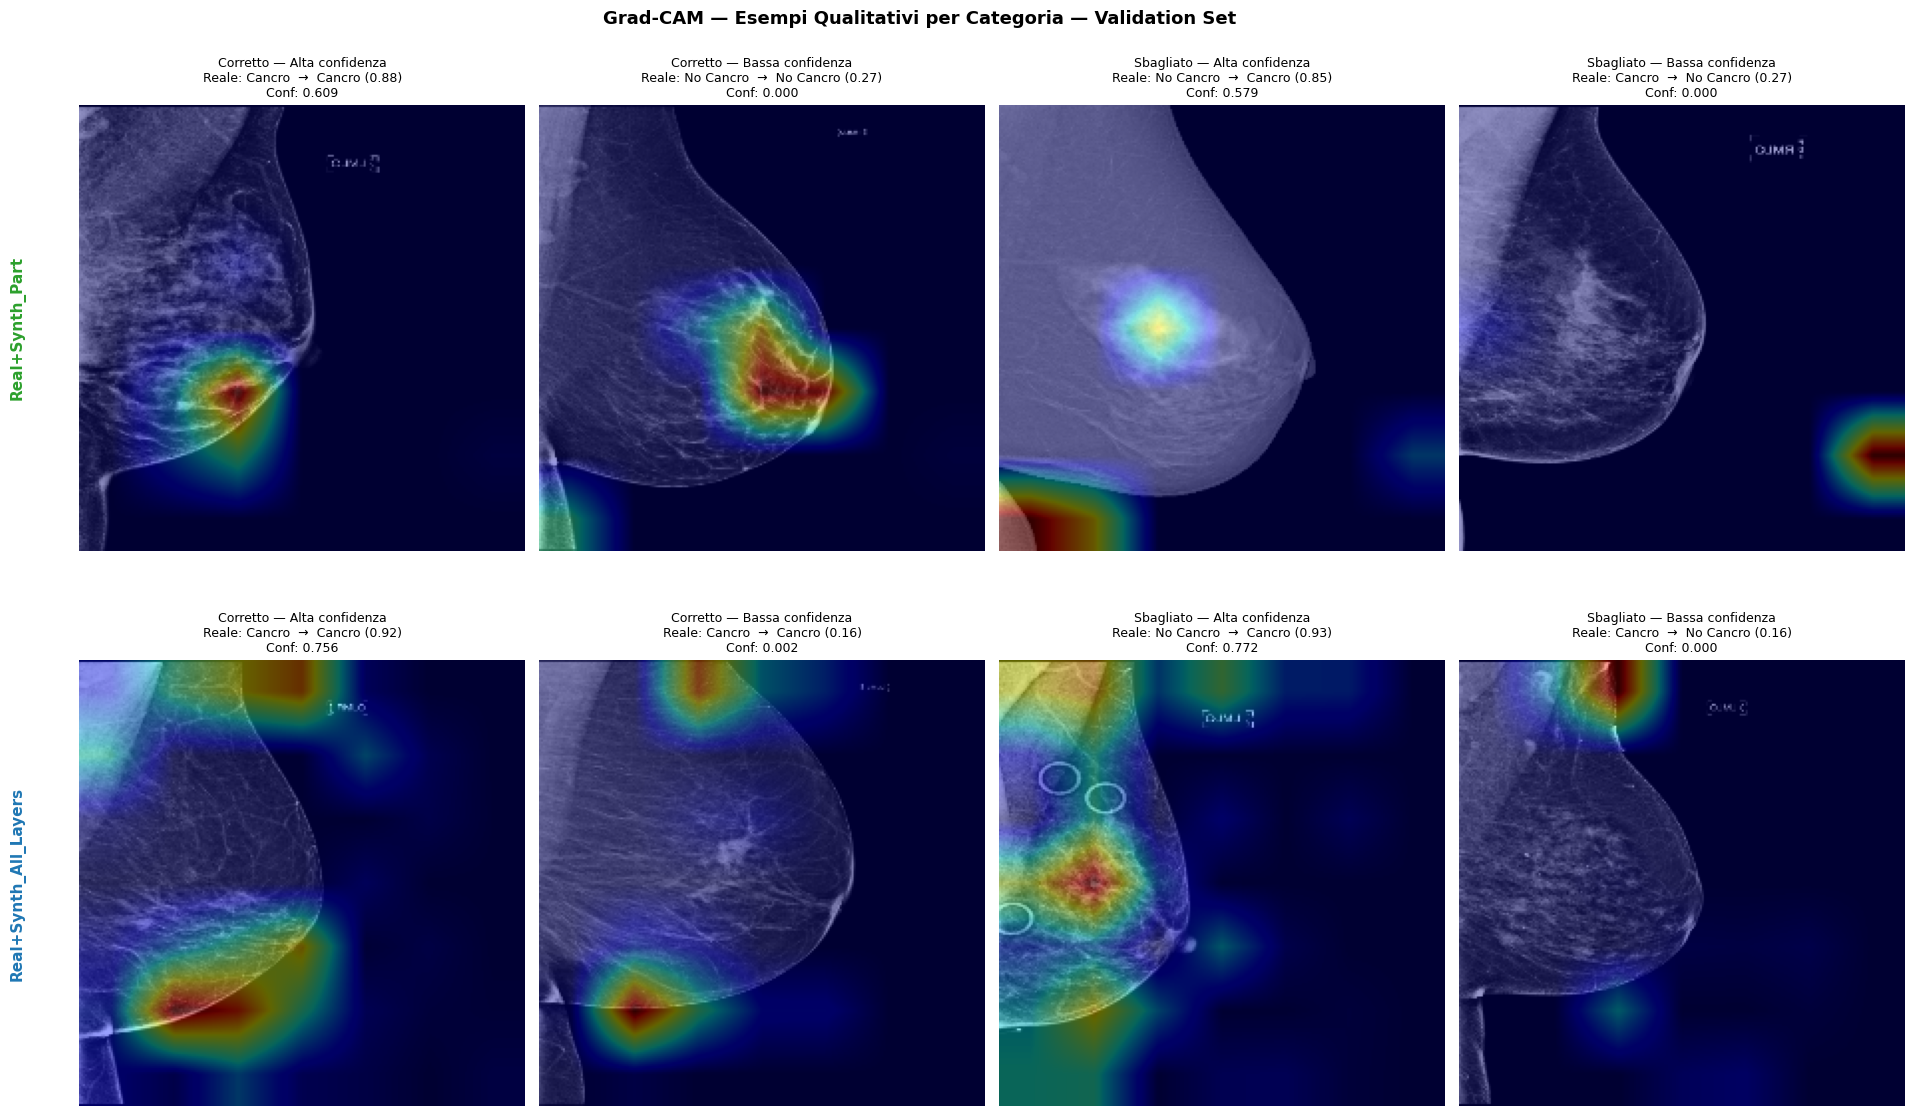

Figura salvata in: ../results/07_val_classificatori_allVSpart/figures/val_gradcam_esempi_qualitativi.png


In [17]:
# Figura: griglia 2 righe (modelli) × 4 colonne (categorie)
nomi_modelli_ord = list(MODELLI_QUALITATIVE.keys())
n_categorie = len(CATEGORIE_QUALITATIVE)

fig, axes = plt.subplots(2, n_categorie, figsize=(n_categorie * 5, 12))

for riga, nome_modello in enumerate(nomi_modelli_ord):
    for col, (cat_key, _, _, etichetta_cat) in enumerate(CATEGORIE_QUALITATIVE):
        ax = axes[riga, col]
        pannello = pannelli_qualitativi.get((nome_modello, cat_key))
        if pannello is None:
            ax.axis('off')
            ax.text(0.5, 0.5, f'{etichetta_cat}\n(nessun campione disponibile)',
                    ha='center', va='center', transform=ax.transAxes, fontsize=9)
        else:
            show_gradcam(pannello['img'], pannello['heatmap'], ax, title=pannello['titolo'])

    axes[riga, 0].text(
        -0.12, 0.5, nome_modello,
        transform=axes[riga, 0].transAxes,
        fontsize=11, fontweight='bold', color=COLORS[nome_modello],
        ha='right', va='center', rotation=90, clip_on=False,
    )

plt.suptitle('Grad-CAM — Esempi Qualitativi per Categoria — Validation Set',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.subplots_adjust(left=0.08)

gradcam_qual_path = os.path.join(FIGURES_DIR, 'val_gradcam_esempi_qualitativi.png')
fig.savefig(gradcam_qual_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Figura salvata in: {gradcam_qual_path}")

#### Visualizzazione — ROC Curves a Confronto

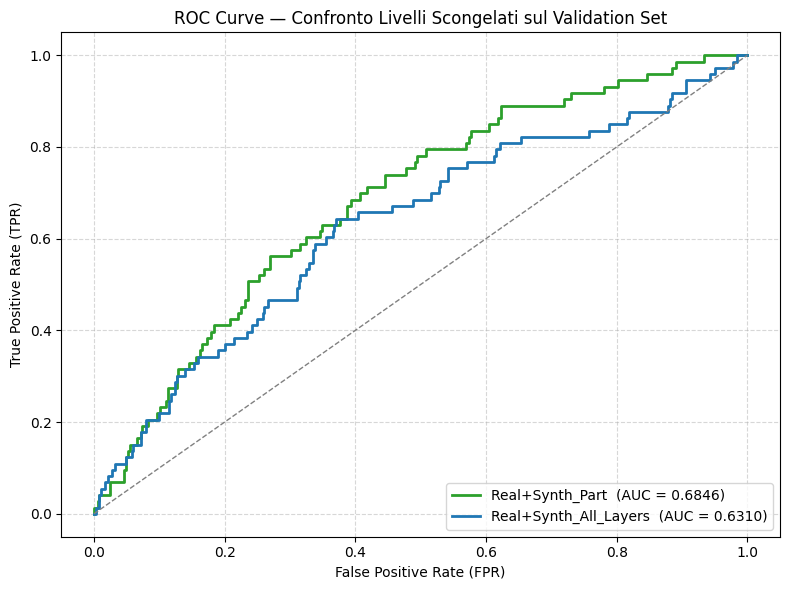

Salvato in: ../results/07_val_classificatori_allVSpart/figures/val_roc_curves.png


In [18]:
fig, ax = plt.subplots(figsize=(8, 6))
for nome_conf, m in all_metrics.items():
    ax.plot(m['fpr'], m['tpr'], color=COLORS[nome_conf], lw=2,
            label=f"{nome_conf}  (AUC = {m['auc']:.4f})")

ax.plot([0, 1], [0, 1], '--', color='gray', linewidth=1)
ax.set_xlabel('False Positive Rate (FPR)')
ax.set_ylabel('True Positive Rate (TPR)')
ax.set_title('ROC Curve — Confronto Livelli Scongelati sul Validation Set')
ax.legend(loc='lower right')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
roc_path = os.path.join(FIGURES_DIR, 'val_roc_curves.png')
fig.savefig(roc_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Salvato in: {roc_path}")

#### Visualizzazione — Matrici di confusione

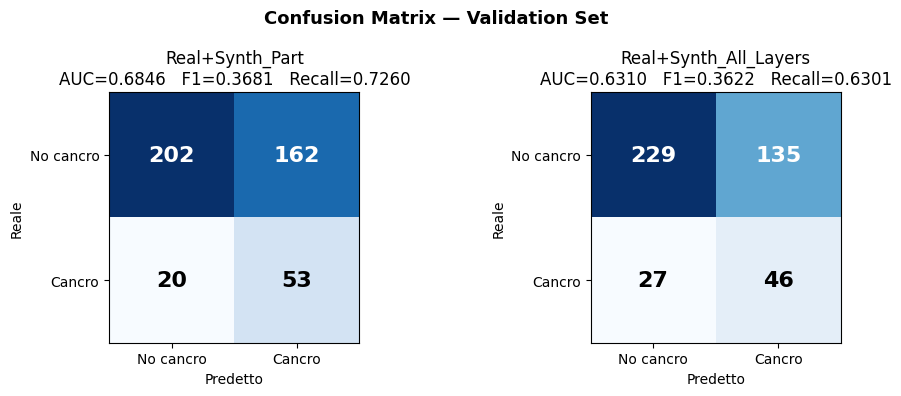

Salvato in: ../results/07_val_classificatori_allVSpart/figures/val_confusion_matrices.png


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (nome_conf, m) in zip(axes, all_metrics.items()):
    cm = confusion_matrix(y_true, m['y_pred'])
    ax.imshow(cm, cmap='Blues')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['No cancro', 'Cancro'])
    ax.set_yticklabels(['No cancro', 'Cancro'])
    ax.set_xlabel('Predetto'); ax.set_ylabel('Reale')
    ax.set_title(f'{nome_conf}\nAUC={m["auc"]:.4f}   F1={m["f1"]:.4f}   Recall={m["recall"]:.4f}')
    for i in range(2):
        for j in range(2):
            color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    fontsize=16, fontweight='bold', color=color)

plt.suptitle('Confusion Matrix — Validation Set', fontsize=13, fontweight='bold')
plt.tight_layout()
cm_path = os.path.join(FIGURES_DIR, 'val_confusion_matrices.png')
fig.savefig(cm_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Salvato in: {cm_path}")

#### Visualizzazione — Confronto Metriche

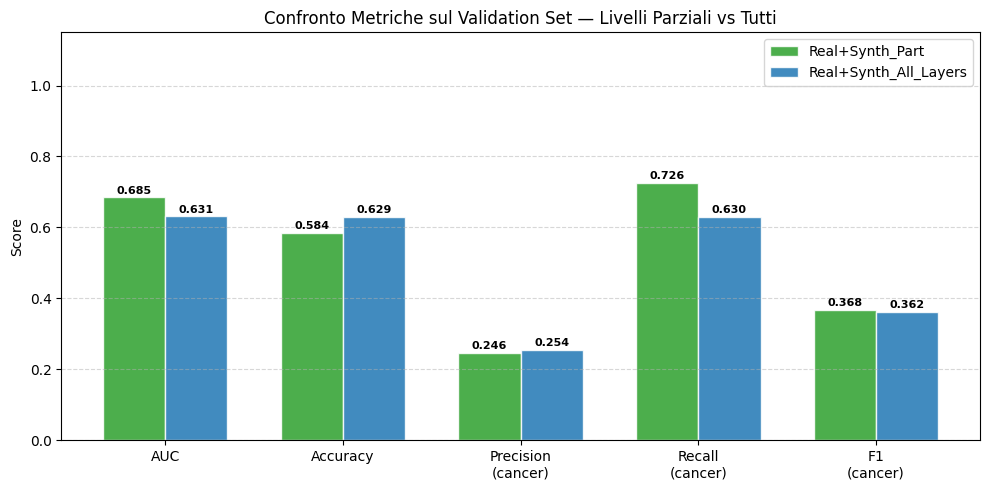

Salvato in: ../results/07_val_classificatori_allVSpart/figures/val_metrics_comparison.png


In [20]:
metric_keys   = ['auc', 'accuracy', 'precision', 'recall', 'f1']
metric_labels = ['AUC', 'Accuracy', 'Precision\n(cancer)', 'Recall\n(cancer)', 'F1\n(cancer)']

x = np.arange(len(metric_keys))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
for i, (nome_conf, color) in enumerate(COLORS.items()):
    vals = [all_metrics[nome_conf][k] for k in metric_keys]
    bars = ax.bar(x + i * width, vals, width, label=nome_conf,
                  color=color, alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x + width / 2)
ax.set_xticklabels(metric_labels)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Confronto Metriche sul Validation Set — Livelli Parziali vs Tutti')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
bar_path = os.path.join(FIGURES_DIR, 'val_metrics_comparison.png')
fig.savefig(bar_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Salvato in: {bar_path}")